In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

n = 2000
dzielnice = ["Mokotów", "Wola", "Śródmieście", "Praga-Południe", "Ursynów",
             "Bemowo", "Białołęka", "Targówek", "Bielany", "Ochota", "Wilanów"]
multiplikator_dzielnicy = {
    "Mokotów": 1.15, "Wola": 1.10, "Śródmieście": 1.40, "Praga-Południe": 0.90,
    "Ursynów": 1.00, "Bemowo": 0.95, "Białołęka": 0.85, "Targówek": 0.88,
    "Bielany": 0.95, "Ochota": 1.05, "Wilanów": 1.20
}

dzielnica = np.random.choice(dzielnice, n)
metraz = np.clip(np.random.normal(55, 22, n), 18, 180)
pokoje = np.clip(np.random.normal(metraz / 18 + np.random.normal(0, 0.5, n)), 1, 6).astype(int)
pietro = np.random.randint(0, 12, n)
rok_budowy = np.random.choice(
    list(range(1950, 2025)),
    n,
    p=np.linspace(0.5, 2, 75) / np.linspace(0.5, 2, 75).sum()
)
ma_balkon = np.random.choice([True, False], n, p=[0.75, 0.25])
ma_miejsce_parkingowe = np.random.choice([True, False], n, p=[0.45, 0.55])
odleglosc_od_centrum = np.clip(np.random.gamma(2.5, 2.5, n), 0.5, 25)

cena_za_m2 = (
    14000
    * np.array([multiplikator_dzielnicy[d] for d in dzielnica])
    * (1 + 0.005 * (rok_budowy - 1980))
    * (1 - 0.015 * odleglosc_od_centrum)
    * (1 + 0.05 * ma_balkon)
    * (1 + 0.08 * ma_miejsce_parkingowe)
    + np.random.normal(0, 1500, n)
)
cena = (cena_za_m2 * metraz).round(0)

df = pd.DataFrame({
    "id_oferty": range(10001, 10001 + n),
    "dzielnica": dzielnica,
    "metraz_m2": metraz.round(1),
    "liczba_pokoi": pokoje,
    "pietro": pietro,
    "rok_budowy": rok_budowy,
    "ma_balkon": ma_balkon,
    "ma_miejsce_parkingowe": ma_miejsce_parkingowe,
    "odleglosc_od_centrum_km": odleglosc_od_centrum.round(2),
    "cena_pln": cena
})

outlier_idx = np.random.choice(df.index, 30, replace=False)
df.loc[outlier_idx[:10], "cena_pln"] *= np.random.uniform(5, 12, 10) 
df.loc[outlier_idx[10:20], "cena_pln"] *= np.random.uniform(0.05, 0.2, 10) 
df.loc[outlier_idx[20:25], "metraz_m2"] = np.random.uniform(300, 600, 5) 
df.loc[outlier_idx[25:30], "rok_budowy"] = np.random.choice([1800, 1850, 2050, 2099], 5)

df.to_csv("mieszkania_warszawa.csv", index=False)
print(f"Wygenerowano plik 'mieszkania_warszawa.csv' - {len(df)} ofert")

Wygenerowano plik 'mieszkania_warszawa.csv' - 2000 ofert


In [4]:
df = pd.read_csv("mieszkania_warszawa.csv")

print("Shape:", df.shape)
print("\nBraki danych:\n", df.isnull().sum())
print("\nInfo:")
df.info()

display(df.describe())

Shape: (2000, 10)

Braki danych:
 id_oferty                  0
dzielnica                  0
metraz_m2                  0
liczba_pokoi               0
pietro                     0
rok_budowy                 0
ma_balkon                  0
ma_miejsce_parkingowe      0
odleglosc_od_centrum_km    0
cena_pln                   0
dtype: int64

Info:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_oferty                2000 non-null   int64  
 1   dzielnica                2000 non-null   str    
 2   metraz_m2                2000 non-null   float64
 3   liczba_pokoi             2000 non-null   int64  
 4   pietro                   2000 non-null   int64  
 5   rok_budowy               2000 non-null   int64  
 6   ma_balkon                2000 non-null   bool   
 7   ma_miejsce_parkingowe    2000 non-null   bool   
 8   odleglosc_od_ce

,id_oferty,metraz_m2,liczba_pokoi,pietro,rok_budowy,odleglosc_od_centrum_km,cena_pln
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,11000.500000,56.657651,2.672000,5.476000,1995.183000,6.398155,8.787505e+05
std,577.494589,27.345451,1.411528,3.441271,20.677096,4.012941,5.928629e+05
min,10001.000000,18.000000,1.000000,0.000000,1950.000000,0.500000,4.189656e+04
25%,10500.750000,40.800000,1.000000,3.000000,1980.000000,3.350000,5.734442e+05
50%,11000.500000,55.300000,3.000000,5.000000,1998.000000,5.535000,8.115230e+05
75%,11500.250000,69.800000,4.000000,8.000000,2013.000000,8.510000,1.088337e+06
max,12000.000000,480.733370,6.000000,11.000000,2099.000000,25.000000,1.056321e+07


W wynikach funkcji describe() widać ogromne rozbieżności w wartościach maksymalnych. Maksymalna cena (cena_pln) oraz metraż (metraz_m2) są oderwane od rzeczywistości (wielokrotnie wyższe niż 75 procent). Dodatkowo w kolumnie rok_budowy pojawiają się daty z przeszłości (1800) oraz z przyszłości (2099), co na pewno jest błędem w danych.

In [5]:
print("--- CENA PLN ---")
print(f"Średnia: {df['cena_pln'].mean():.2f}")
print(f"Mediana: {df['cena_pln'].median():.2f}")
print(f"Odchylenie std: {df['cena_pln'].std():.2f}")
print(f"Skośność (skewness): {df['cena_pln'].skew():.2f}")
print(f"Kurtoza (kurtosis): {df['cena_pln'].kurt():.2f}")

q1 = df['metraz_m2'].quantile(0.25)
q3 = df['metraz_m2'].quantile(0.75)
print(f"\n--- METRAŻ ---")
print(f"Q1: {q1}, Q3: {q3}, IQR: {q3 - q1}")

print(f"\nUnikalne dzielnice: {df['dzielnica'].nunique()}")
print(df['dzielnica'].value_counts())

--- CENA PLN ---
Średnia: 878750.48
Mediana: 811523.00
Odchylenie std: 592862.89
Skośność (skewness): 8.04
Kurtoza (kurtosis): 110.84

--- METRAŻ ---
Q1: 40.8, Q3: 69.8, IQR: 29.0

Unikalne dzielnice: 11
dzielnica
Mokotów           210
Targówek          189
Ursynów           189
Śródmieście       189
Ochota            188
Wola              178
Białołęka         177
Bemowo            176
Bielany           174
Praga-Południe    166
Wilanów           164
Name: count, dtype: int64


Skośność dla ceny jest bardzo wysoka i dodatnia. Oznacza to, że rozkład jest prawostronnie skośny. Większość mieszkań skupia się wokół umiarkowanych cen (po lewej stronie osi), ale istnieje bardzo długi ogon skrajnie drogich mieszkań (outlierów), który ciągnie średnią mocno w górę.

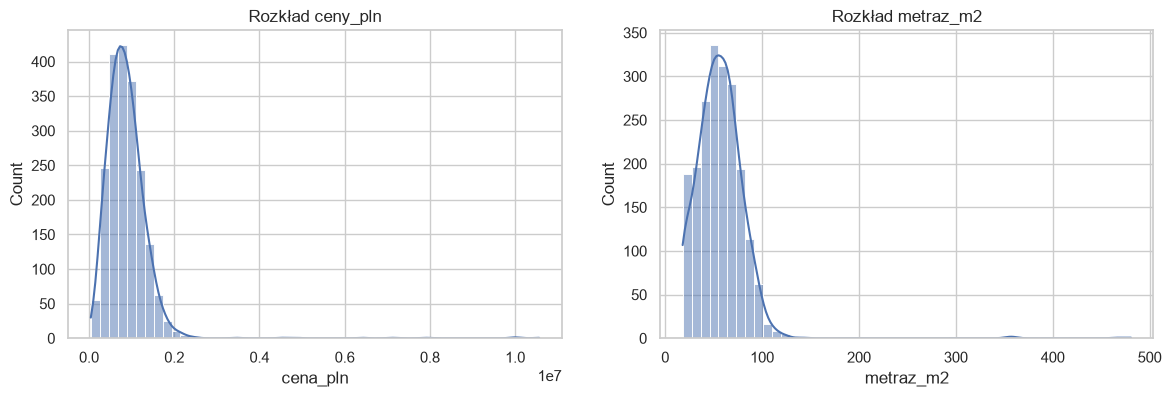

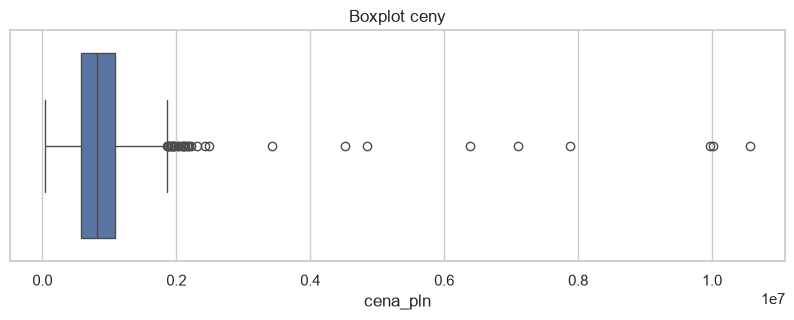

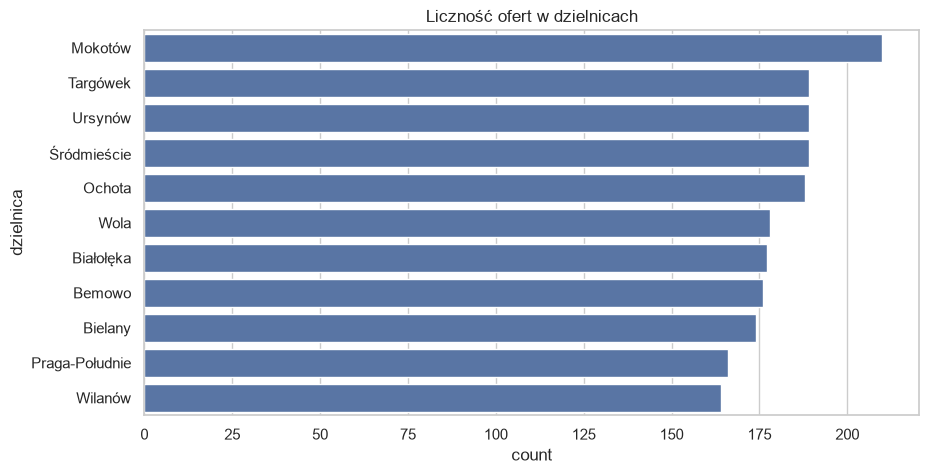

In [6]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['cena_pln'], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Rozkład ceny_pln")
sns.histplot(df['metraz_m2'], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Rozkład metraz_m2")
plt.show()

plt.figure(figsize=(10, 3))
sns.boxplot(x=df['cena_pln'])
plt.title("Boxplot ceny")
plt.show()

plt.figure(figsize=(10, 5))
kolejnosc = df['dzielnica'].value_counts().index
sns.countplot(data=df, y='dzielnica', order=kolejnosc)
plt.title("Liczność ofert w dzielnicach")
plt.show()

Na histogramach wyraźnie widać skośność — długi płaski ogon z prawej strony. Boxplot ceny doskonale to obrazuje: główna część danych (pudełko) jest bardzo wąska i ściśnięta po lewej, a cała reszta wykresu to czarne kropki oznaczające outliery (ekstremalnie drogie mieszkania).

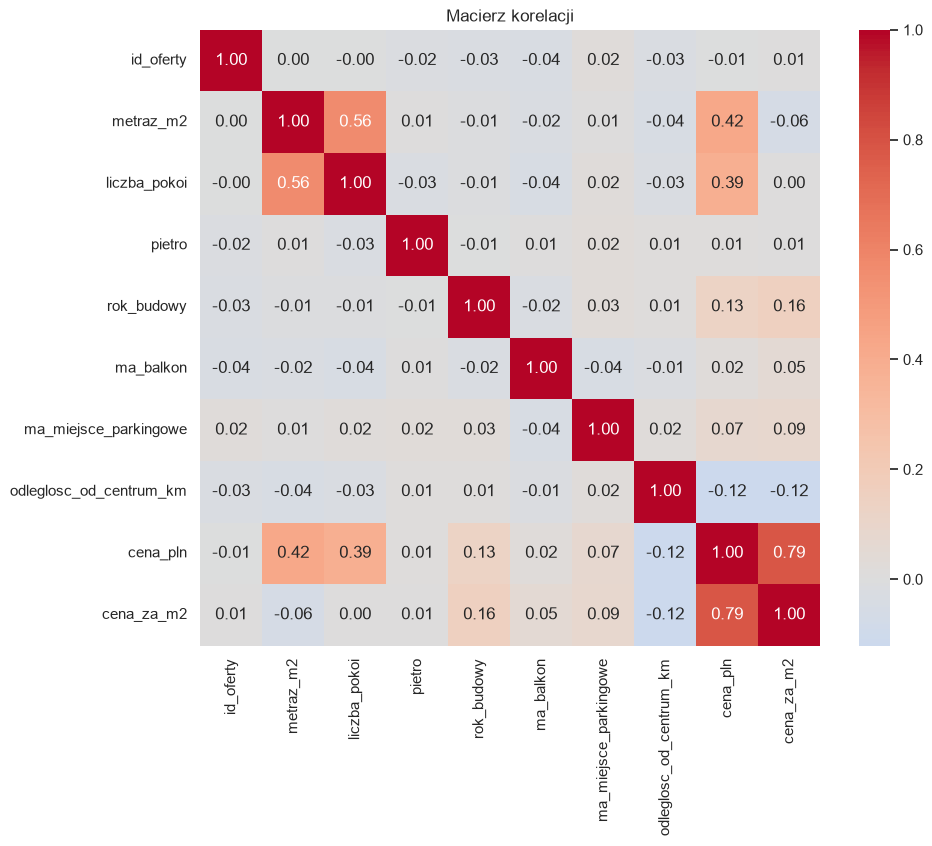

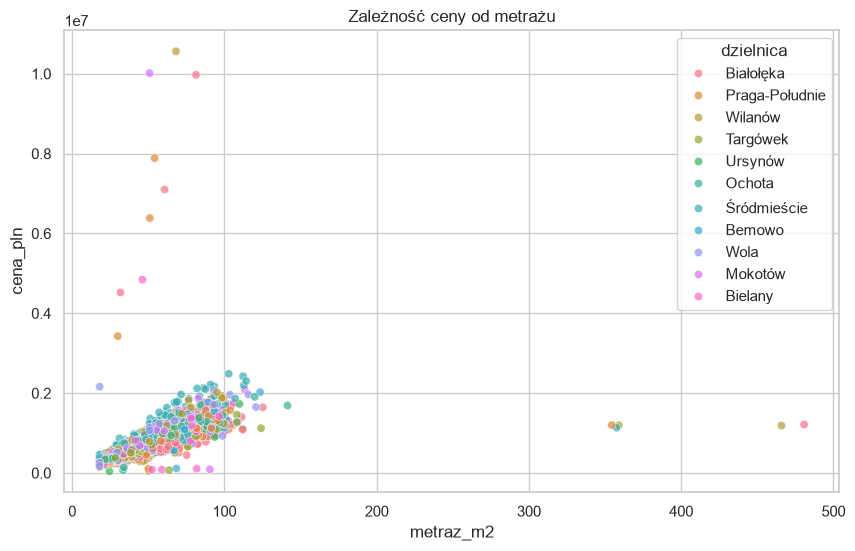

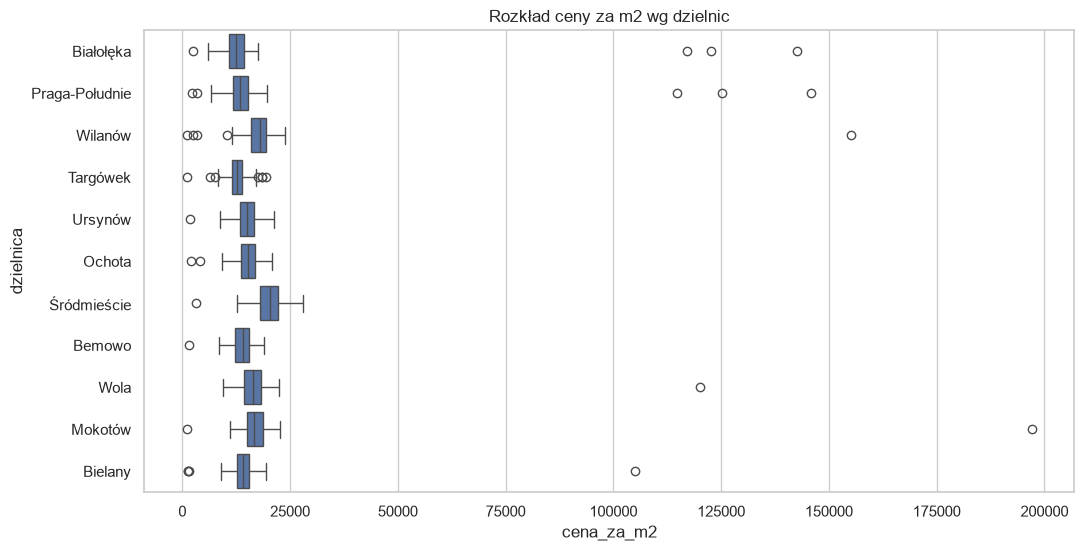

In [7]:
df_corr = df.copy()
df_corr["ma_balkon"] = df_corr["ma_balkon"].astype(int)
df_corr["ma_miejsce_parkingowe"] = df_corr["ma_miejsce_parkingowe"].astype(int)
df_corr["cena_za_m2"] = df_corr["cena_pln"] / df_corr["metraz_m2"]
df["cena_za_m2"] = df_corr["cena_za_m2"] 
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Macierz korelacji")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='metraz_m2', y='cena_pln', hue='dzielnica', alpha=0.7)
plt.title("Zależność ceny od metrażu")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='cena_za_m2', y='dzielnica')
plt.title("Rozkład ceny za m2 wg dzielnic")
plt.show()

Z ceną (cena_pln) najsilniej koreluje metraż (metraz_m2). Współczynnik korelacji z heatmapy jest bliski 1.

Analizując boxplot cena_za_m2, widać jasno, że dzielnicą o najwyższych cenach za metr kwadratowy jest Śródmieście.

In [8]:
q1_c = df['cena_pln'].quantile(0.25)
q3_c = df['cena_pln'].quantile(0.75)
iqr_c = q3_c - q1_c
out_iqr = df[(df['cena_pln'] < q1_c - 1.5*iqr_c) | (df['cena_pln'] > q3_c + 1.5*iqr_c)]

z_scores = np.abs(stats.zscore(df['cena_pln']))
out_z = df[z_scores > 3]

med = df['cena_pln'].median()
mad = stats.median_abs_deviation(df['cena_pln'])
mod_z_scores = 0.6745 * (df['cena_pln'] - med) / mad
out_mod_z = df[np.abs(mod_z_scores) > 3.5]

print(f"Outliery w cena_pln (IQR): {len(out_iqr)}")
print(f"Outliery w cena_pln (Z-score): {len(out_z)}")
print(f"Outliery w cena_pln (Mod Z-score): {len(out_mod_z)}")

q1_m = df['metraz_m2'].quantile(0.25)
q3_m = df['metraz_m2'].quantile(0.75)
iqr_m = q3_m - q1_m
out_metraz = df[(df['metraz_m2'] < q1_m - 1.5*iqr_m) | (df['metraz_m2'] > q3_m + 1.5*iqr_m)]
print("\nTop 5 największych metraży:")
display(out_metraz.nlargest(5, 'metraz_m2')[['id_oferty', 'metraz_m2']])

bzdury_lata = df[(df['rok_budowy'] < 1900) | (df['rok_budowy'] > 2026)]
print(f"\nZnaleziono {len(bzdury_lata)} wierszy z błędnym rokiem:")
display(bzdury_lata[['id_oferty', 'rok_budowy']])

Outliery w cena_pln (IQR): 34
Outliery w cena_pln (Z-score): 9
Outliery w cena_pln (Mod Z-score): 17

Top 5 największych metraży:


,id_oferty,metraz_m2
1836,11837,480.733370
1829,11830,465.849130
242,10243,359.005921
749,10750,357.494768
1949,11950,354.319203



Znaleziono 5 wierszy z błędnym rokiem:


,id_oferty,rok_budowy
170,10171,2050
273,10274,2099
1108,11109,2050
1777,11778,2050
1797,11798,2099


Skośność przed log: 8.04
Skośność po log: -0.49


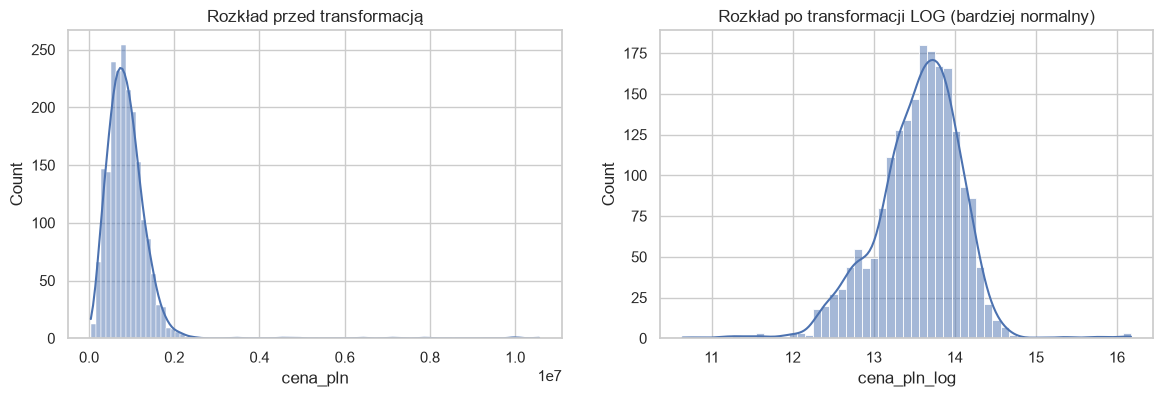

In [9]:
df_clean = df[(df['rok_budowy'] >= 1900) & (df['rok_budowy'] <= 2026)].copy()

p1 = df_clean['cena_pln'].quantile(0.01)
p99 = df_clean['cena_pln'].quantile(0.99)
df_clean['cena_pln_capped'] = df_clean['cena_pln'].clip(lower=p1, upper=p99)

df_clean['cena_pln_log'] = np.log1p(df_clean['cena_pln'])

print(f"Skośność przed log: {df_clean['cena_pln'].skew():.2f}")
print(f"Skośność po log: {df_clean['cena_pln_log'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_clean['cena_pln'], kde=True, ax=axes[0])
axes[0].set_title("Rozkład przed transformacją")
sns.histplot(df_clean['cena_pln_log'], kde=True, ax=axes[1])
axes[1].set_title("Rozkład po transformacji LOG (bardziej normalny)")
plt.show()

Identyfikacja anomalii w surowych danych to obowiązek: Badanie statystyk (m.in. maksimum i IQR) oraz boxplotów bezlitośnie ujawniło zanieczyszczenie zbioru – sztucznie narzucone outliery cenowe i niemożliwe lata budowy (1800/2099). Zawsze trzeba to wyczyścić przed ewentualnym modelowaniem.

Metraż jest głównym motorem napędowym całkowitej ceny: Zarówno heatmapa korelacji, jak i wykres punktowy udowodniły niezwykle silną zależność liniową między wielkością mieszkania a jego ceną końcową.

Transformacja logarytmiczna normuje dane finansowe: Ceny na rynku nieruchomości posiadają długi prawy ogon (dodatnia skośność). Zastosowanie zwykłego logarytmu sprawiło, że dystrybucja "zbiła" rozstrzelone dane i przyjęła znacznie łagodniejszy, symetryczny kształt, podobny do rozkładu normalnego.